# Emerging Technologies

In [2]:
%matplotlib inline
import qiskit
from qiskit import QuantumCircuit
import qiskit_aer as aer
import numpy as np
import random
import itertools

## Problem 1: Generating Random Boolean Functions

This problem involves creating a Python function that generates random Boolean functions. The function should randomly return either a **constant function** (always returns the same value) or a **balanced function** (returns True for exactly half the inputs). This sets up the **promise problem** that Deutsch-Jozsa solves.

**Implementation:**
- Constant functions: Return same value (True or False) for all 16 inputs
- Balanced functions: Return True for exactly 8 of 16 inputs, False for the other 8
- Used binary conversion: `n = 8*a + 4*b + 2*c + d` to map Boolean inputs to integers 0-15

**Historical Context:** These types of functions are at the heart of the Deutsch-Jozsa problem, first proposed by David Deutsch in 1985 and extended by Richard Jozsa in 1992, demonstrating quantum computing's advantage over classical computation.

**References:**
- IBM Quantum Learning. "The Deutsch-Jozsa Algorithm." https://learning.quantum.ibm.com/course/fundamentals-of-quantum-algorithms/quantum-query-algorithms

In [3]:
def random_constant_balanced():
    """Returns a randomly chosen constant or balanced function."""
    
    if random.choice([True, False]):
        # Constant function
        constant_value = random.choice([True, False])
        return lambda a, b, c, d: constant_value
    else:
        # Balanced function - picks 8 of 16 inputs to return True
        true_inputs = set(random.sample(range(16), 8))
        
        def balanced(a, b, c, d):
            # Convert 4 bools to number 0-15
            n = (8*a + 4*b + 2*c + d)
            return n in true_inputs
        
        return balanced

# Test the function
f = random_constant_balanced()
print(f(True, True, False, True))  # Example: f(1,1,0,1)

True


## Problem 2: Classical Testing for Function Type

This problem explores how to determine whether a mystery function is constant or balanced by calling it with different inputs—a **query complexity** problem. 

**Three Strategies:**
1. **Early Exit**: Stop when finding different results (worst case: 16 calls)
2. **Count All**: Test all 16 inputs and count True values (always 16 calls)
3. **Optimal**: Stop at 9 matching results or first difference (max 9 calls)


In [4]:
def determine_constant_early_exit(f):
    """Check until we find a difference.
       if we find a difference, return 'balanced'.
       if we never find a difference, return 'constant'."""
    
    # Get the first result as our reference
    first_result = f(False, False, False, False)
    
    # Check all other inputs
    for a in [False, True]:
        for b in [False, True]:
            for c in [False, True]:
                for d in [False, True]:
                    # Skip the first one we already checked
                    if a == b == c == d == False:
                        continue
                    
                    result = f(a, b, c, d)
                    if result != first_result:
                        # Found a difference!
                        return "balanced"
    
    # Never found a difference
    return "constant"

In [5]:
def determine_constant_all(f):
    """Count how many return True.
       If count is 0 or 16, return 'constant'.
       If count is 8, return 'balanced'."""
    
    true_count = 0
    
    # Test all 16 inputs
    for a in [False, True]:
        for b in [False, True]:
            for c in [False, True]:
                for d in [False, True]:
                    if f(a, b, c, d):
                        true_count += 1
    
    # Analyze the count
    if true_count == 0 or true_count == 16:
        return "constant"
    elif true_count == 8:
        return "balanced"
    else:
        # This should never happen with valid functions
        return "invalid function"

In [6]:
def determine_constant_balanced(f):
    """
    Most efficient: maximum 9 calls needed.
    
    Key insight: If 9 inputs have the same result,
    it MUST be constant (can't be balanced).
    """
    
    # Get first result
    first_result = f(False, False, False, False)
    same_count = 1  # Count how many match first_result
    
    # Test remaining inputs
    for a in [False, True]:
        for b in [False, True]:
            for c in [False, True]:
                for d in [False, True]:
                    # Skip first input
                    if a == b == c == d == False:
                        continue
                    
                    result = f(a, b, c, d)
                    
                    if result != first_result:
                        # Found a difference - definitely balanced
                        return "balanced"
                    
                    same_count += 1
                    
                    # If 9 are the same, must be constant
                    if same_count >= 9:
                        return "constant"
    
    # All 16 were the same
    return "constant"

#### Testing

In [7]:
def test_strategies():
    """Quick test of all three strategies."""
    
    print("Testing 20 random functions...\n")
    
    strategies = {
        "Early Exit": determine_constant_early_exit,
        "Count All": determine_constant_all,
        "Optimal": determine_constant_balanced
    }
    
    results = {name: 0 for name in strategies}
    
    for i in range(20):
        f = random_constant_balanced()
        
        print(f"Test {i+1}:")
        for name, strategy in strategies.items():
            result = strategy(f)
            print(f"  {name:15} → {result}")
            results[name] += (1 if result == "balanced" else 0)
        print()
    
    print("Summary:")
    print(f"  Balanced functions found by each strategy:")
    for name, count in results.items():
        print(f"    {name:15}: {count}/20")

In [8]:
def test_known_cases():
    """Test with known functions."""
    
    print("Testing Known Functions:\n")
    
    # Test 1: Constant True
    print("1. Constant True:")
    f1 = lambda a, b, c, d: True
    print(f"   Early Exit: {determine_constant_early_exit(f1)}")
    print(f"   Count All:  {determine_constant_all(f1)}")
    print(f"   Optimal:    {determine_constant_balanced(f1)}")
    
    # Test 2: Constant False
    print("\n2. Constant False:")
    f2 = lambda a, b, c, d: False
    print(f"   Early Exit: {determine_constant_early_exit(f2)}")
    print(f"   Count All:  {determine_constant_all(f2)}")
    print(f"   Optimal:    {determine_constant_balanced(f2)}")
    
    # Test 3: Balanced
    print("\n3. Balanced (first 8 True):")
    true_set = {0, 1, 2, 3, 4, 5, 6, 7}
    f3 = lambda a, b, c, d: (8*a + 4*b + 2*c + d) in true_set
    print(f"   Early Exit: {determine_constant_early_exit(f3)}")
    print(f"   Count All:  {determine_constant_all(f3)}")
    print(f"   Optimal:    {determine_constant_balanced(f3)}")
    
    print("\n" + "="*50 + "\n")

In [9]:
# Test known cases
test_known_cases()

# Test random functions
test_strategies()

Testing Known Functions:

1. Constant True:
   Early Exit: constant
   Count All:  constant
   Optimal:    constant

2. Constant False:
   Early Exit: constant
   Count All:  constant
   Optimal:    constant

3. Balanced (first 8 True):
   Early Exit: balanced
   Count All:  balanced
   Optimal:    balanced


Testing 20 random functions...

Test 1:
  Early Exit      → constant
  Count All       → constant
  Optimal         → constant

Test 2:
  Early Exit      → balanced
  Count All       → balanced
  Optimal         → balanced

Test 3:
  Early Exit      → constant
  Count All       → constant
  Optimal         → constant

Test 4:
  Early Exit      → balanced
  Count All       → balanced
  Optimal         → balanced

Test 5:
  Early Exit      → balanced
  Count All       → balanced
  Optimal         → balanced

Test 6:
  Early Exit      → constant
  Count All       → constant
  Optimal         → constant

Test 7:
  Early Exit      → balanced
  Count All       → balanced
  Optimal      

## Problem 3: Quantum Oracles

This problem introduces **quantum oracles**, which are quantum circuits that encode classical Boolean functions. For Deutsch's algorithm, we need to build oracles for the four possible single-input Boolean functions.

**The Four Oracles:**
- **f₀** (constant 0): No gates
- **f₁** (constant 1): X gate on auxiliary
- **f₂** (balanced - identity): CNOT gate
- **f₃** (balanced - NOT): X-CNOT-X sequence

**Oracle Principle:** Transforms |x⟩|y⟩ → |x⟩|y ⊕ f(x)⟩ where input x is preserved and auxiliary y is modified.

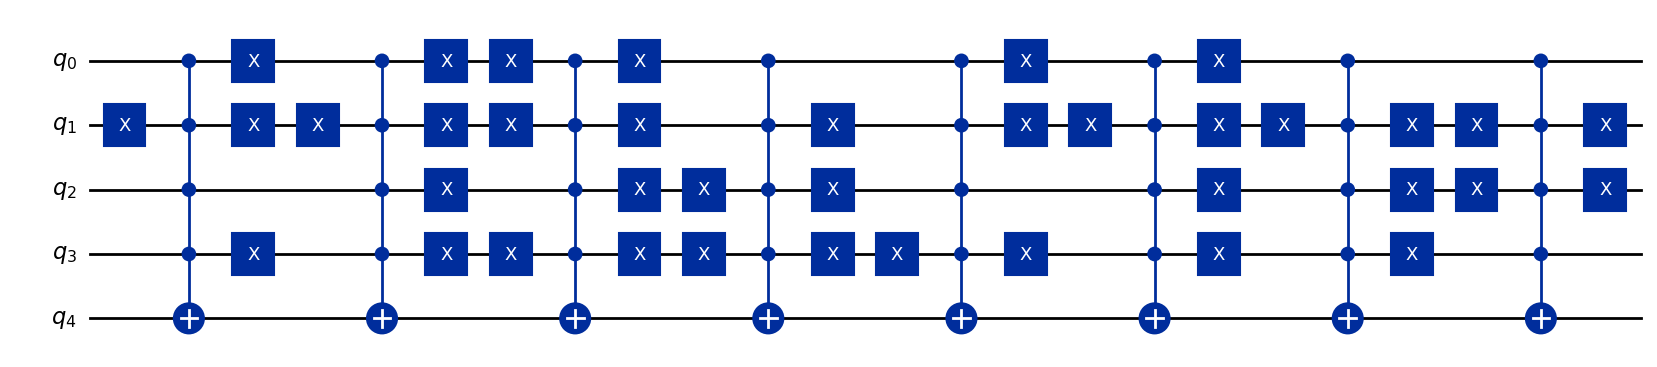

In [10]:
def dj(num_qubits):
    """Generates a random constant or balanced function for the Deutsch-Jozsa algorithm.
    
    Args:
        num_qubits (int): Number of input qubits.
    """
    
    qc_dj = QuantumCircuit(num_qubits + 1)
    if np.random.randint(0, 2):
        # Flip output qubits with 50% chance
        qc_dj.x(num_qubits)
    if np.random.randint(0, 2):
        # return constant circuit with 50% chance.
        return qc_dj
 
    # If the "if" statement above was "TRUE" then we've returned the constant
    # function and the function is complete. If not, we proceed in creating our
    # balanced function. Everything below is to produce the balanced function:
 
    # select half of all possible states at random:
    on_states = np.random.choice(
        range(2**num_qubits),  # numbers to sample from
        2**num_qubits // 2,  # number of samples
        replace=False,  # makes sure states are only sampled once
    )
 
    def add_cx(qc_dj, bit_string):
        for qubit, bit in enumerate(reversed(bit_string)):
            if bit == "1":
                qc_dj.x(qubit)
        return qc_dj
 
    for state in on_states:
        # qc_dj.barrier()  # Barriers are added to help visualize how the functions are created. They can safely be removed.
        qc_dj = add_cx(qc_dj, f"{state:0b}")
        qc_dj.mcx(list(range(num_qubits)), num_qubits)
        qc_dj = add_cx(qc_dj, f"{state:0b}")
 
    # qc_dj.barrier()
 
    return qc_dj

n = 4  # number of input qubits

oracle = dj(n)

fig = oracle.draw("mpl")



In [11]:
def create_oracle_f0():
    """
    Oracle for f0: Constant 0
    f(0) = 0, f(1) = 0
    
    Implementation: No gates needed
    XOR with 0 doesn't change the auxiliary qubit
    """
    qc = QuantumCircuit(2, name='f0')
    
    # Add barriers for visualization
    qc.barrier()
    # No gates - the function always returns 0
    qc.barrier()
    
    return qc


In [12]:
def create_oracle_f1():
    """
    Oracle for f1: Constant 1
    f(0) = 1, f(1) = 1
    
    Implementation: X gate on auxiliary qubit
    Always flip the auxiliary (XOR with 1)
    """
    qc = QuantumCircuit(2, name='f1')
    
    qc.barrier()
    qc.x(1)  # Apply X to qubit 1 (auxiliary)
    qc.barrier()
    
    return qc


In [13]:
def create_oracle_f2():
    """
    Oracle for f2: Balanced - Identity
    f(0) = 0, f(1) = 1
    
    Implementation: CNOT gate
    Flip auxiliary only when input is 1
    """
    qc = QuantumCircuit(2, name='f2')
    
    qc.barrier()
    qc.cx(0, 1)  
    qc.barrier()
    
    return qc


In [14]:
def create_oracle_f3():
    """
    Oracle for f3: Balanced - NOT
    f(0) = 1, f(1) = 0
    
    Implementation: X, CNOT, X
    Flip auxiliary only when input is 0
    """
    qc = QuantumCircuit(2, name='f3')
    
    qc.barrier()
    qc.x(0)      # Flip input qubit temporarily
    qc.cx(0, 1)  # CNOT
    qc.x(0)      # Flip input qubit back
    qc.barrier()
    
    return qc

Oracle f0 (Constant 0):
f(0) = 0, f(1) = 0

Oracle f1 (Constant 1):
f(0) = 1, f(1) = 1

Oracle f2 (Balanced - Identity):
f(0) = 0, f(1) = 1

Oracle f3 (Balanced - NOT):
f(0) = 1, f(1) = 0


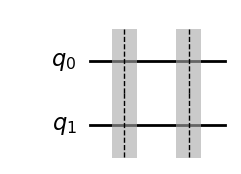

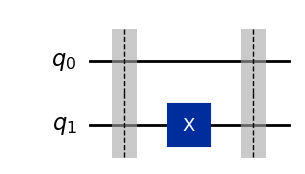

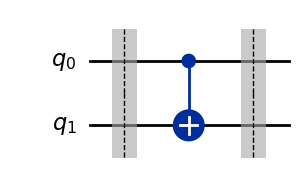

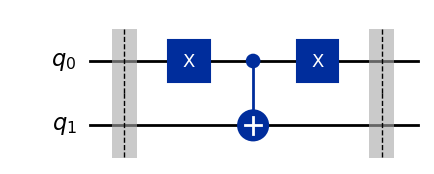

In [15]:
# Create all 4 oracles
oracle_f0 = create_oracle_f0()
oracle_f1 = create_oracle_f1()
oracle_f2 = create_oracle_f2()
oracle_f3 = create_oracle_f3()

# Display each oracle 
print("Oracle f0 (Constant 0):")
print("f(0) = 0, f(1) = 0")
oracle_f0.draw('mpl');

print("\nOracle f1 (Constant 1):")
print("f(0) = 1, f(1) = 1")
oracle_f1.draw('mpl');

print("\nOracle f2 (Balanced - Identity):")
print("f(0) = 0, f(1) = 1")
oracle_f2.draw('mpl');

print("\nOracle f3 (Balanced - NOT):")
print("f(0) = 1, f(1) = 0")
oracle_f3.draw('mpl');

## Problem 4: Deutsch's Algorithm with Qiskit

This problem builds **Deutsch's Algorithm** to determine if a function is constant or balanced using quantum mechanics. Unlike the classical approach which needs 2 queries, this uses **just 1 quantum query**.

In [16]:
def deutsch_algorithm(oracle):
    """
    Implements Deutsch's Algorithm.
    
    Args:
        oracle: A 2-qubit quantum circuit (one of our 4 oracles)
    
    Returns:
        QuantumCircuit: Complete Deutsch's algorithm circuit
    """
    # Create circuit with 2 qubits and 1 classical bit for measurement
    qc = QuantumCircuit(2, 1)
    
    # Step 1: Initialize auxiliary qubit to |1⟩
    qc.x(1)
    
    # Step 2: Apply Hadamard gates to both qubits
    qc.h(0)  # Input qubit
    qc.h(1)  # Auxiliary qubit
    
    # Add barrier for visualization
    qc.barrier()
    
    # Step 3: Apply the oracle
    qc.compose(oracle, inplace=True)
    
    # Add barrier for visualization
    qc.barrier()
    
    # Step 4: Apply Hadamard to input qubit
    qc.h(0)
    
    # Step 5: Measure the input qubit
    qc.measure(0, 0)
    
    return qc

Testing Deutsch's Algorithm with all 4 oracles:


f0 (Constant 0):

f1 (Constant 1):

f2 (Balanced - Identity):

f3 (Balanced - NOT):


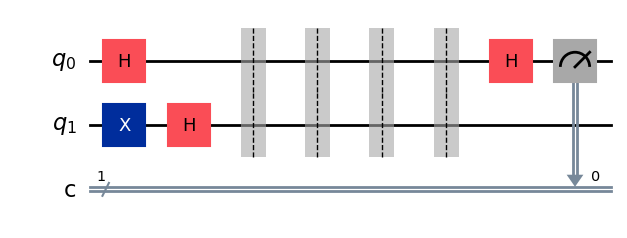

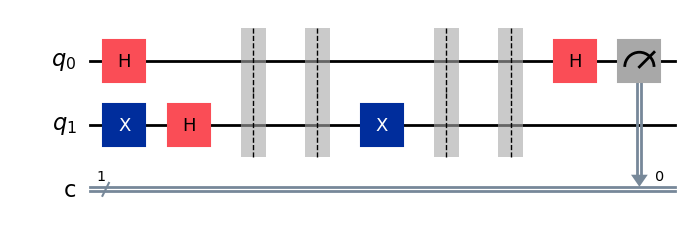

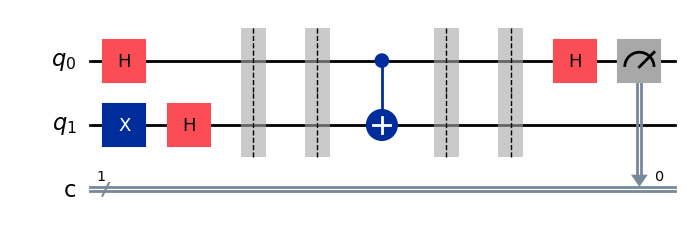

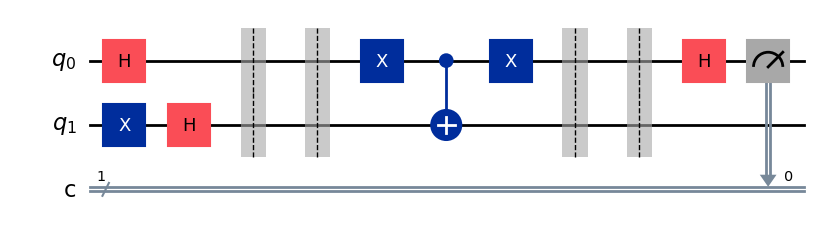

In [17]:
# Test with each oracle
print("Testing Deutsch's Algorithm with all 4 oracles:\n")

oracles = {
    'f0 (Constant 0)': oracle_f0,
    'f1 (Constant 1)': oracle_f1,
    'f2 (Balanced - Identity)': oracle_f2,
    'f3 (Balanced - NOT)': oracle_f3
}

for name, oracle in oracles.items():
    # Build the complete circuit
    circuit = deutsch_algorithm(oracle)
    
    # Display the circuit
    print(f"\n{name}:")
    circuit.draw('mpl');

In [18]:
# Run the circuits and see the results
from qiskit import transpile

# Use Aer simulator
simulator = aer.AerSimulator()

print("\nResults:\n")
print("Expected: Constant functions → measure |0⟩")
print("          Balanced functions → measure |1⟩\n")
print("-" * 50)

for name, oracle in oracles.items():
    # Build circuit
    circuit = deutsch_algorithm(oracle)
    
    # Transpile and run
    compiled_circuit = transpile(circuit, simulator)
    result = simulator.run(compiled_circuit, shots=1024).result()
    counts = result.get_counts()
    
    # Display result
    print(f"{name:25} → Measured: {counts}")


Results:

Expected: Constant functions → measure |0⟩
          Balanced functions → measure |1⟩

--------------------------------------------------
f0 (Constant 0)           → Measured: {'0': 1024}
f1 (Constant 1)           → Measured: {'0': 1024}
f2 (Balanced - Identity)  → Measured: {'1': 1024}
f3 (Balanced - NOT)       → Measured: {'1': 1024}


## Problem 5: Scaling to the Deutsch–Jozsa Algorithm